# Trying to Classify Non Sepranle Dataset Using Quantum ML techniques

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler , OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.circuit.library import zz_feature_map, real_amplitudes

from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils import algorithm_globals


In [2]:
algorithm_globals.random_seed = 42
np.random.seed(42)

In [3]:
features , labels = make_moons(
    n_samples=200,
    noise=0.15,
    random_state=42
)

In [4]:
scaler = MinMaxScaler()

features = scaler.fit_transform(features)

In [5]:
print(features.shape)
print(labels.shape)

(200, 2)
(200,)


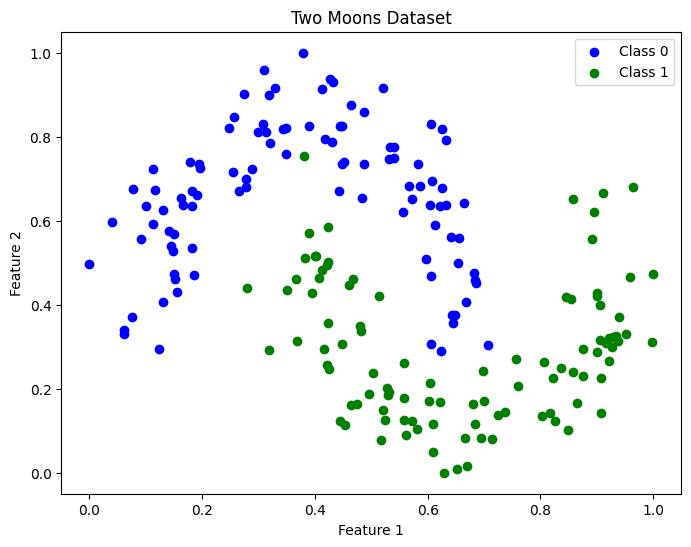

In [6]:
def plot_dataset():
    plt.figure(figsize=(8,6))

    plt.scatter(
        features[labels == 0, 0],
        features[labels == 0, 1],
        color="blue",
        label="Class 0"
    )

    plt.scatter(
        features[labels == 1, 0],
        features[labels == 1, 1],
        color="green",
        label="Class 1"
    )

    plt.title("Two Moons Dataset")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.legend()
    plt.show()

plot_dataset()

In [7]:
train_features , test_features , train_labels , test_lables = train_test_split(
    features , labels , test_size=0.2 , random_state=42
)

In [8]:
print("Train Features Shape :", train_features.shape)
print("Test Features Shape  :", test_features.shape)

print("Train Labels Shape   :", train_labels.shape)
print("Test Labels Shape    :", test_lables.shape)

Train Features Shape : (160, 2)
Test Features Shape  : (40, 2)
Train Labels Shape   : (160,)
Test Labels Shape    : (40,)


## Logistic Regrssion

In [9]:
log_model = LogisticRegression()

log_model.fit(train_features , train_labels)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [10]:
train_score = log_model.score(train_features, train_labels)

test_score = log_model.score(test_features, test_lables)

print("Train Accuracy :", train_score)
print("Test Accuracy  :", test_score)

Train Accuracy : 0.85625
Test Accuracy  : 0.85


In [11]:
train_predictions = log_model.predict(train_features)

test_predictions = log_model.predict(test_features)

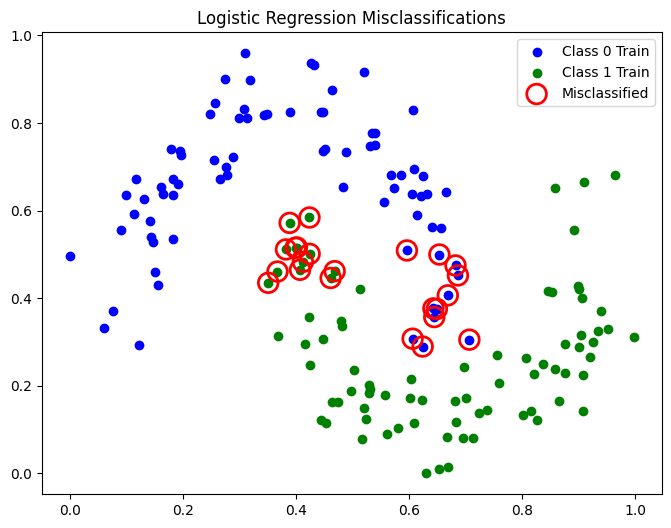

In [12]:
plt.figure(figsize=(8,6))

# Correct class visualization
plt.scatter(
    train_features[train_labels == 0, 0],
    train_features[train_labels == 0, 1],
    color="blue",
    label="Class 0 Train"
)

plt.scatter(
    train_features[train_labels == 1, 0],
    train_features[train_labels == 1, 1],
    color="green",
    label="Class 1 Train"
)

# Misclassified points
plt.scatter(
    train_features[train_labels != train_predictions, 0],
    train_features[train_labels != train_predictions, 1],
    s=200,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    label="Misclassified"
)

plt.title("Logistic Regression Misclassifications")
plt.legend()
plt.show()

### As expected the Logisitc regression failed to classify some lables due to non linearly seprable data! and as in the picture there is many miss classified labels

## Support Vector Machine (SVM)

In [13]:
svm_model = SVC(kernel='rbf')

svm_model.fit(train_features , train_labels)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [14]:
train_score = svm_model.score(train_features , train_labels)

test_score = svm_model.score(test_features , test_lables)

In [15]:
print("Train Accuracy :", train_score)
print("Test Accuracy  :", test_score)

Train Accuracy : 0.98125
Test Accuracy  : 0.975


In [16]:
train_predictions = svm_model.predict(train_features)

test_predictions = svm_model.predict(test_features)

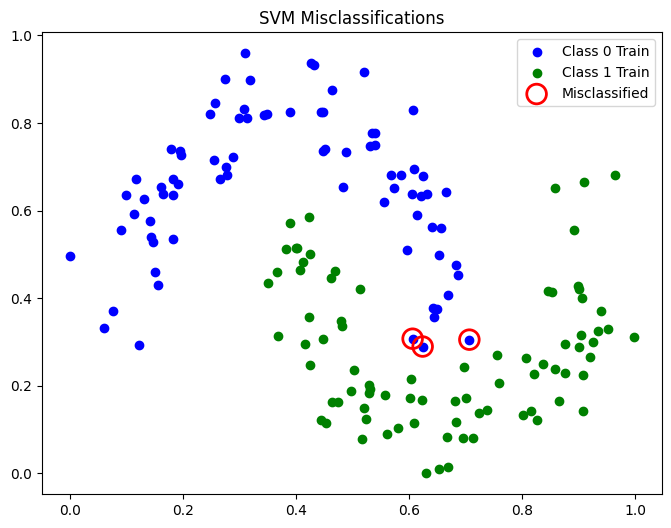

In [17]:
plt.figure(figsize=(8,6))

# Correct class visualization
plt.scatter(
    train_features[train_labels == 0, 0],
    train_features[train_labels == 0, 1],
    color="blue",
    label="Class 0 Train"
)

plt.scatter(
    train_features[train_labels == 1, 0],
    train_features[train_labels == 1, 1],
    color="green",
    label="Class 1 Train"
)

# Misclassified points
plt.scatter(
    train_features[train_labels != train_predictions, 0],
    train_features[train_labels != train_predictions, 1],
    s=200,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    label="Misclassified"
)

plt.title("SVM Misclassifications")
plt.legend()
plt.show()

### As expected the SVM perfomred good on this dataset because we applyed the kernel trick RBF where we increase the dims of the dataset and then try to find the plane that classify the both labels 

## VQC Model

In [18]:
encoder = OneHotEncoder(sparse_output=False)

train_labels_q = encoder.fit_transform(
    train_labels.reshape(-1 , 1)
)

test_labels_q = encoder.transform(
    test_lables.reshape(-1 , 1)
)

In [19]:
print(train_labels_q.shape)
print(test_labels_q.shape)

(160, 2)
(40, 2)


In [20]:
samper = Sampler()

In [ ]:
feature_map = zz_feature_map(
    feature_dimension=2,
    reps=2
)

C:\Users\shara\AppData\Local\Temp\ipykernel_9016\378075580.py:1: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


In [22]:
optimizer = COBYLA(maxiter=100)

In [ ]:
ansatz = real_amplitudes(
    num_qubits=2,
    reps=3
)

C:\Users\shara\AppData\Local\Temp\ipykernel_9016\1348485252.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(


In [24]:
vqc = VQC(
    sampler=samper,
    feature_map=feature_map,
    optimizer=optimizer,
    ansatz=ansatz
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


In [25]:
vqc.fit(train_features , train_labels_q)

In [26]:
train_score = vqc.score(train_features, train_labels_q)

test_score = vqc.score(test_features, test_labels_q)

print("Train Accuracy :", train_score)
print("Test Accuracy  :", test_score)

Train Accuracy : 0.71875
Test Accuracy  : 0.75


In [27]:
train_predictions = vqc.predict(train_features)

test_predictions = vqc.predict(test_features)

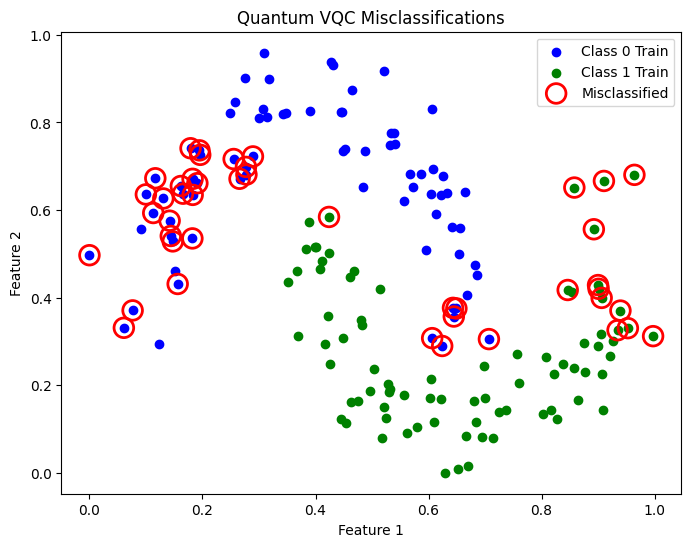

In [29]:
# Convert one-hot labels to integer labels
train_labels_int = np.argmax(train_labels_q, axis=1)

# Convert predictions to integer labels
train_predictions_int = np.argmax(train_predictions, axis=1)

plt.figure(figsize=(8,6))

# Class 0
plt.scatter(
    train_features[train_labels_int == 0, 0],
    train_features[train_labels_int == 0, 1],
    color="blue",
    label="Class 0 Train"
)

# Class 1
plt.scatter(
    train_features[train_labels_int == 1, 0],
    train_features[train_labels_int == 1, 1],
    color="green",
    label="Class 1 Train"
)

# Misclassified points
plt.scatter(
    train_features[train_labels_int != train_predictions_int, 0],
    train_features[train_labels_int != train_predictions_int, 1],
    s=200,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    label="Misclassified"
)

plt.title("Quantum VQC Misclassifications")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()
plt.show()

### The current quantum architecture and optimization setup are insufficient to model the nonlinear structure effectively.

# Hyperparameter Exploration for VQC

In [30]:
results = []
feature_map_reps_list = [1,2,3,4]
ansatz_reps_list = [1,2,3,4,5]
maxiter_list = [50,100,200]

In [ ]:
for fmap_reps in feature_map_reps_list:

    for ansatz_reps in ansatz_reps_list:

        for max_iter in maxiter_list:

            print("=" * 60)
            print(f"Feature Map Reps : {fmap_reps}")
            print(f"Ansatz Reps      : {ansatz_reps}")
            print(f"Max Iterations   : {max_iter}")

            try:

                # Feature Map
                feature_map = zz_feature_map(
                    feature_dimension=2,
                    reps=fmap_reps
                )

                # Ansatz
                ansatz = real_amplitudes(
                    num_qubits=2,
                    reps=ansatz_reps
                )

                # Optimizer
                optimizer = COBYLA(maxiter=max_iter)

                # VQC Model
                vqc = VQC(
                    sampler=samper,
                    feature_map=feature_map,
                    ansatz=ansatz,
                    optimizer=optimizer
                )

                # Train
                vqc.fit(train_features, train_labels_q)

                # Scores
                train_score = vqc.score(
                    train_features,
                    train_labels_q
                )

                test_score = vqc.score(
                    test_features,
                    test_labels_q
                )

                print(f"Train Accuracy : {train_score:.4f}")
                print(f"Test Accuracy  : {test_score:.4f}")

                # Save Results
                results.append({
                    "feature_map_reps": fmap_reps,
                    "ansatz_reps": ansatz_reps,
                    "maxiter": max_iter,
                    "train_accuracy": train_score,
                    "test_accuracy": test_score
                })

            except Exception as e:

                print("Experiment Failed")
                print(e)

C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Feature Map Reps : 1
Ansatz Reps      : 1
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7125
Test Accuracy  : 0.6750
Feature Map Reps : 1
Ansatz Reps      : 1
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7125
Test Accuracy  : 0.6750
Feature Map Reps : 1
Ansatz Reps      : 1
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7063
Test Accuracy  : 0.6750
Feature Map Reps : 1
Ansatz Reps      : 2
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.6625
Test Accuracy  : 0.7000
Feature Map Reps : 1
Ansatz Reps      : 2
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.5500
Test Accuracy  : 0.5500
Feature Map Reps : 1
Ansatz Reps      : 2
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.5687
Test Accuracy  : 0.5250
Feature Map Reps : 1
Ansatz Reps      : 3
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7937
Test Accuracy  : 0.6500
Feature Map Reps : 1
Ansatz Reps      : 3
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7625
Test Accuracy  : 0.7750
Feature Map Reps : 1
Ansatz Reps      : 3
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7875
Test Accuracy  : 0.7250
Feature Map Reps : 1
Ansatz Reps      : 4
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.8063
Test Accuracy  : 0.7000
Feature Map Reps : 1
Ansatz Reps      : 4
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.6438
Test Accuracy  : 0.5250
Feature Map Reps : 1
Ansatz Reps      : 4
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7750
Test Accuracy  : 0.7500
Feature Map Reps : 1
Ansatz Reps      : 5
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.5875
Test Accuracy  : 0.5250
Feature Map Reps : 1
Ansatz Reps      : 5
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.8063
Test Accuracy  : 0.6750
Feature Map Reps : 1
Ansatz Reps      : 5
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.6687
Test Accuracy  : 0.5500
Feature Map Reps : 2
Ansatz Reps      : 1
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.8125
Test Accuracy  : 0.8000
Feature Map Reps : 2
Ansatz Reps      : 1
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.8187
Test Accuracy  : 0.7500
Feature Map Reps : 2
Ansatz Reps      : 1
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7625
Test Accuracy  : 0.7250
Feature Map Reps : 2
Ansatz Reps      : 2
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7250
Test Accuracy  : 0.6750
Feature Map Reps : 2
Ansatz Reps      : 2
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.6937
Test Accuracy  : 0.7000
Feature Map Reps : 2
Ansatz Reps      : 2
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7937
Test Accuracy  : 0.7500
Feature Map Reps : 2
Ansatz Reps      : 3
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7562
Test Accuracy  : 0.7500
Feature Map Reps : 2
Ansatz Reps      : 3
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7000
Test Accuracy  : 0.7000
Feature Map Reps : 2
Ansatz Reps      : 3
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7188
Test Accuracy  : 0.6500
Feature Map Reps : 2
Ansatz Reps      : 4
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7188
Test Accuracy  : 0.7250
Feature Map Reps : 2
Ansatz Reps      : 4
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7063
Test Accuracy  : 0.6750
Feature Map Reps : 2
Ansatz Reps      : 4
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7000
Test Accuracy  : 0.6250
Feature Map Reps : 2
Ansatz Reps      : 5
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.6875
Test Accuracy  : 0.6250
Feature Map Reps : 2
Ansatz Reps      : 5
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7625
Test Accuracy  : 0.7500
Feature Map Reps : 2
Ansatz Reps      : 5
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.6937
Test Accuracy  : 0.7250
Feature Map Reps : 3
Ansatz Reps      : 1
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.6312
Test Accuracy  : 0.6750
Feature Map Reps : 3
Ansatz Reps      : 1
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.6937
Test Accuracy  : 0.6750
Feature Map Reps : 3
Ansatz Reps      : 1
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.6500
Test Accuracy  : 0.5750
Feature Map Reps : 3
Ansatz Reps      : 2
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7875
Test Accuracy  : 0.7750
Feature Map Reps : 3
Ansatz Reps      : 2
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7500
Test Accuracy  : 0.7000
Feature Map Reps : 3
Ansatz Reps      : 2
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7500
Test Accuracy  : 0.7750
Feature Map Reps : 3
Ansatz Reps      : 3
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.5750
Test Accuracy  : 0.6000
Feature Map Reps : 3
Ansatz Reps      : 3
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7562
Test Accuracy  : 0.8000
Feature Map Reps : 3
Ansatz Reps      : 3
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7562
Test Accuracy  : 0.6750
Feature Map Reps : 3
Ansatz Reps      : 4
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7625
Test Accuracy  : 0.6750
Feature Map Reps : 3
Ansatz Reps      : 4
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7812
Test Accuracy  : 0.7000
Feature Map Reps : 3
Ansatz Reps      : 4
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7250
Test Accuracy  : 0.7750
Feature Map Reps : 3
Ansatz Reps      : 5
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7438
Test Accuracy  : 0.7000
Feature Map Reps : 3
Ansatz Reps      : 5
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.8000
Test Accuracy  : 0.8000
Feature Map Reps : 3
Ansatz Reps      : 5
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7875
Test Accuracy  : 0.7750
Feature Map Reps : 4
Ansatz Reps      : 1
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7812
Test Accuracy  : 0.7750
Feature Map Reps : 4
Ansatz Reps      : 1
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7937
Test Accuracy  : 0.8000
Feature Map Reps : 4
Ansatz Reps      : 1
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.8063
Test Accuracy  : 0.7500
Feature Map Reps : 4
Ansatz Reps      : 2
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7937
Test Accuracy  : 0.7750
Feature Map Reps : 4
Ansatz Reps      : 2
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7000
Test Accuracy  : 0.6750
Feature Map Reps : 4
Ansatz Reps      : 2
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7688
Test Accuracy  : 0.7500
Feature Map Reps : 4
Ansatz Reps      : 3
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.8625
Test Accuracy  : 0.7750
Feature Map Reps : 4
Ansatz Reps      : 3
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.9000
Test Accuracy  : 0.8500
Feature Map Reps : 4
Ansatz Reps      : 3
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.8438
Test Accuracy  : 0.8250
Feature Map Reps : 4
Ansatz Reps      : 4
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.8750
Test Accuracy  : 0.7750
Feature Map Reps : 4
Ansatz Reps      : 4
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.8250
Test Accuracy  : 0.7750
Feature Map Reps : 4
Ansatz Reps      : 4
Max Iterations   : 200


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.8125
Test Accuracy  : 0.7250
Feature Map Reps : 4
Ansatz Reps      : 5
Max Iterations   : 50


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.8000
Test Accuracy  : 0.7750
Feature Map Reps : 4
Ansatz Reps      : 5
Max Iterations   : 100


C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:15: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\886725467.py:21: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train Accuracy : 0.7812
Test Accuracy  : 0.8000
Feature Map Reps : 4
Ansatz Reps      : 5
Max Iterations   : 200
Train Accuracy : 0.7750
Test Accuracy  : 0.8000


In [ ]:
!pip install pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\shara\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [44]:
import pandas as pd
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="test_accuracy",
    ascending=False
)

results_df.to_csv(
    "vqc_hyperparameter_results.csv",
    index=False
)
results_df.head(10)

,feature_map_reps,ansatz_reps,maxiter,train_accuracy,test_accuracy
52,4,3,100,0.90000,0.850
53,4,3,200,0.84375,0.825
15,2,1,50,0.81250,0.800
43,3,5,100,0.80000,0.800
37,3,3,100,0.75625,0.800
59,4,5,200,0.77500,0.800
46,4,1,100,0.79375,0.800
58,4,5,100,0.78125,0.800
35,3,2,200,0.75000,0.775
7,1,3,100,0.76250,0.775


In [45]:
best_result = results_df.iloc[0]

print(best_result)

feature_map_reps      4.00
ansatz_reps           3.00
maxiter             100.00
train_accuracy        0.90
test_accuracy         0.85
Name: 52, dtype: float64


In [37]:
print("Best VQC Configuration")
print("=" * 40)

print("Feature Map Reps :", best_result["feature_map_reps"])
print("Ansatz Reps      :", best_result["ansatz_reps"])
print("Max Iterations   :", best_result["maxiter"])

print("Train Accuracy   :", best_result["train_accuracy"])
print("Test Accuracy    :", best_result["test_accuracy"])

Best VQC Configuration
Feature Map Reps : 4.0
Ansatz Reps      : 3.0
Max Iterations   : 100.0
Train Accuracy   : 0.9
Test Accuracy    : 0.85


In [38]:
feature_map_reps = 4
ansatz_reps = 3
max_iterations = 100

In [ ]:
best_feature_map = zz_feature_map(
    feature_dimension=2,
    reps=4
)

best_ansatz = real_amplitudes(
    num_qubits=2,
    reps=3
)

best_optimizer = COBYLA(
    maxiter=100
)

best_vqc = VQC(
    sampler=samper,
    feature_map=best_feature_map,
    ansatz=best_ansatz,
    optimizer=best_optimizer
)

best_vqc.fit(train_features, train_labels_q)

C:\Users\shara\AppData\Local\Temp\ipykernel_9016\1083184612.py:1: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  best_feature_map = ZZFeatureMap(
C:\Users\shara\AppData\Local\Temp\ipykernel_9016\1083184612.py:6: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  best_ansatz = RealAmplitudes(
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


In [40]:
train_score = best_vqc.score(
    train_features,
    train_labels_q
)

test_score = best_vqc.score(
    test_features,
    test_labels_q
)

print("Train Accuracy :", train_score)
print("Test Accuracy  :", test_score)

Train Accuracy : 0.8
Test Accuracy  : 0.775


In [41]:
train_predictions = best_vqc.predict(train_features)

test_predictions = best_vqc.predict(test_features)

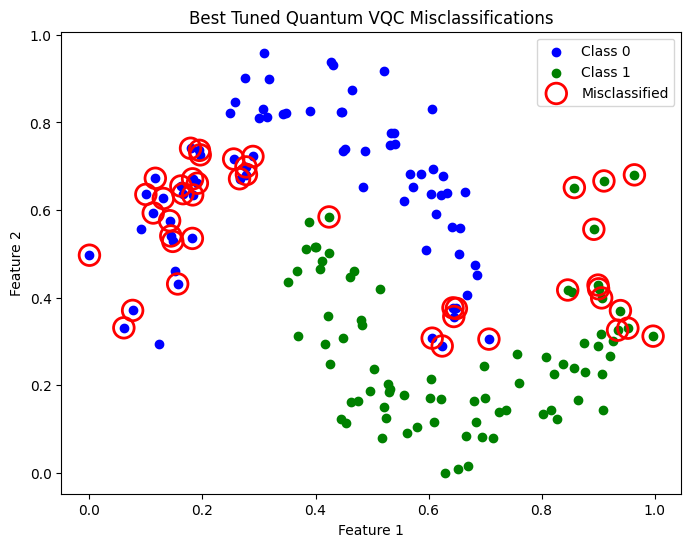

In [42]:
plt.figure(figsize=(8,6))

# Class 0
plt.scatter(
    train_features[train_labels_int == 0, 0],
    train_features[train_labels_int == 0, 1],
    color="blue",
    label="Class 0"
)

# Class 1
plt.scatter(
    train_features[train_labels_int == 1, 0],
    train_features[train_labels_int == 1, 1],
    color="green",
    label="Class 1"
)

# Misclassified points
plt.scatter(
    train_features[
        train_labels_int != train_predictions_int, 0
    ],
    train_features[
        train_labels_int != train_predictions_int, 1
    ],
    s=220,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    label="Misclassified"
)

plt.title("Best Tuned Quantum VQC Misclassifications")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()
plt.show()

### well the accuary is diffrent here and diffrent in again trainng due to Stochastic Quantum Optimization Behavior of the Quantum ML techniques ! 

### Optimizer Can Converge to DIFFERENT parameter regions.

### right now my “quantum model” is actually running on classical hardware. But if we use QPU then we might get diffrent outputs ! 